In [54]:
import pandas as pd
import numpy as np
from numpy import polyfit

import xarray as xr

import matplotlib.pyplot as plt

from bluemath_tk.tcs.tracks import get_category

In [64]:
#### User inputs
models = ['ec_earth3_veg_lr'] 
scenarios = ['historical', 'ssp245', 'ssp585']
n_sim = 1
p_min_trks = {}

for model in models:
    for ssp in scenarios:

        p_min_trks[(model, ssp)] = []

        simulated_daily_bmus = xr.open_dataset(f'outputs/tc_logit/{model}/{ssp}/simulated_tracktypes_with_tc_id_{model}_{ssp}.nc')
        emu_tracks = xr.open_dataset(f'outputs/tc_logit/{model}/{ssp}/emu_tracks_{model}_{ssp}_corrected.nc')
        print(f'outputs/tc_logit/{model}/{ssp}/emu_tracks_{model}_{ssp}_corrected.nc')

        vmax = emu_tracks['vmax_trks']

        for track in emu_tracks.storm_number.values:
            sim = emu_tracks['sim_number'].sel(storm_number=track).values
            if sim != n_sim:
                continue
            else:
                track_pmin = emu_tracks['pmin_trks'].sel(storm_number=track).values
                max_intensity = np.nanmin(track_pmin)
                p_min_trks[(model, ssp)].append(max_intensity)

outputs/tc_logit/ec_earth3_veg_lr/historical/emu_tracks_ec_earth3_veg_lr_historical_corrected.nc
outputs/tc_logit/ec_earth3_veg_lr/ssp245/emu_tracks_ec_earth3_veg_lr_ssp245_corrected.nc
outputs/tc_logit/ec_earth3_veg_lr/ssp585/emu_tracks_ec_earth3_veg_lr_ssp585_corrected.nc


In [56]:
category_counts = {}

for model in models:
    for ssp in scenarios:
        p_min_list = p_min_trks[(model, ssp)]
        category_counts[(model, ssp)] = get_category(np.array(p_min_list))

category_counts_norm = {}
for model in models:
    for ssp in scenarios:
        counts = category_counts[(model, ssp)]
        cat, n_cat = np.unique(counts, return_counts=True)
        category_counts_norm[(model, ssp)] = n_cat / np.sum(n_cat)

In [57]:
df = pd.DataFrame(
    {k[1]: v for k, v in category_counts_norm.items()}
).T

df.columns = [f"bin_{i}" for i in range(df.shape[1])]
df.index.name = "scenario"

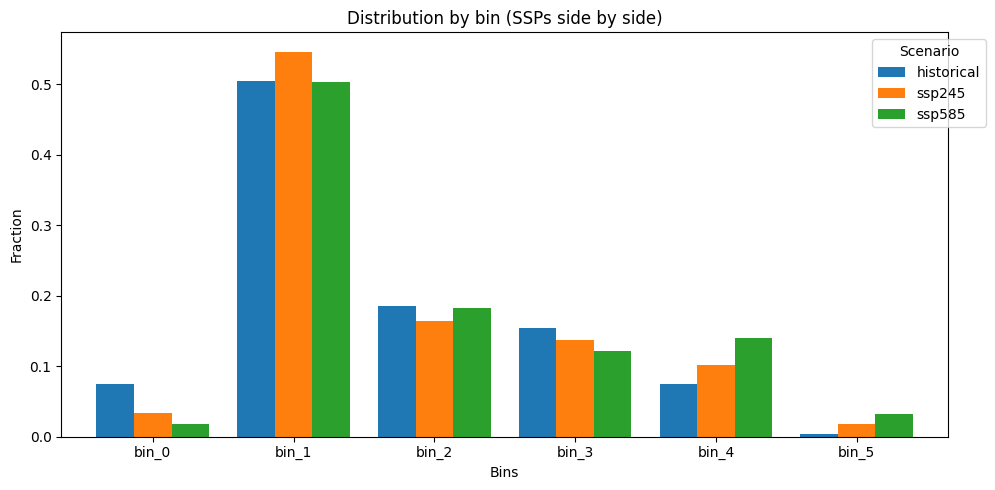

In [58]:
df_plot = df.T 

ax = df_plot.plot(
    kind="bar",
    figsize=(10,5),
    width=0.8
)

plt.title("Distribution by bin (SSPs side by side)")
plt.xlabel("Bins")
plt.ylabel("Fraction")
plt.xticks(rotation=0)
plt.legend(title="Scenario", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [59]:
#### Ibtracks
ibtracks = pd.read_csv('inputs/track_types_hist_with_cat.csv')

In [60]:
obs_dist = (
    ibtracks['category']
    .value_counts(normalize=True)
    .sort_index()
)

In [61]:
obs_dist

category
0    0.123862
1    0.486339
2    0.116576
3    0.143898
4    0.109290
5    0.020036
Name: proportion, dtype: float64

In [62]:
df_plot

scenario,historical,ssp245,ssp585
bin_0,0.075157,0.033074,0.017895
bin_1,0.505219,0.546693,0.504211
bin_2,0.185804,0.163424,0.183158
bin_3,0.154489,0.137160,0.122105
bin_4,0.075157,0.101167,0.140000
bin_5,0.004175,0.018482,0.032632


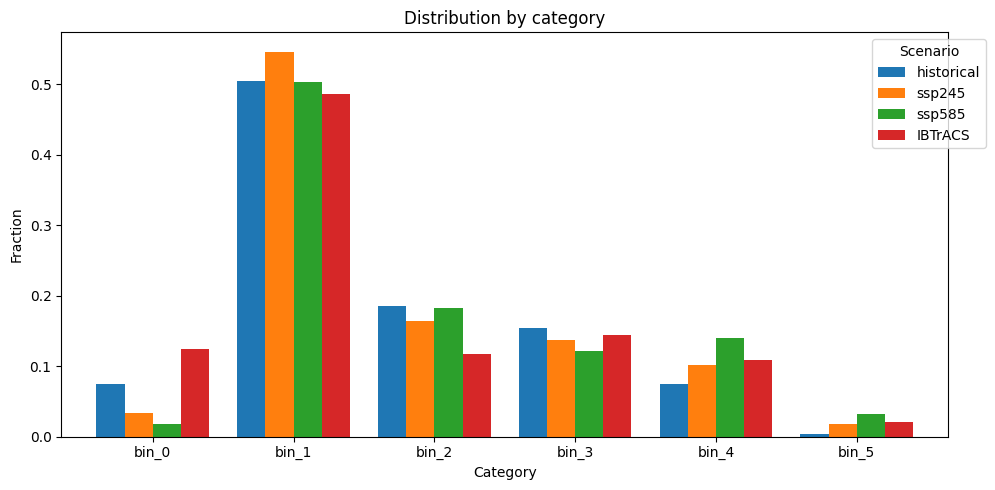

In [63]:
df.loc['IBTrACS'] = obs_dist.values

df_plot = df.T

ax = df_plot.plot(
    kind='bar',
    figsize=(10,5),
    width=0.8
)

plt.title("Distribution by category")
plt.xlabel("Category")
plt.ylabel("Fraction")
plt.xticks(rotation=0)
plt.legend(title="Scenario", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()